#### 🔌 Importing core dependencies | 🏗️ XTALLET

In [1]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.prebuilt import ToolNode, tools_condition

#### 🧠 Initializing the chat model | 🏗️ XTALLET

In [2]:
from langchain.chat_models import init_chat_model
model = init_chat_model("openai:gpt-4.1")

#### 🔗 Connecting to the MCP server | 🏗️ XTALLET

In [3]:
client = MultiServerMCPClient(
    {
        "news": {
            "command": "python",
            "args": ["./activity1_server.py"],
            "transport": "stdio",
        }
    }
)

#### 🛠️ Loading available tools from the MCP server | 🏗️ XTALLET

In [4]:
tools = await client.get_tools()

#### 📤 Printing retrieved tools | 🏗️ XTALLET

In [5]:
tools

[StructuredTool(name='get_top_headlines', description='Get top headlines from News API for a specific country and optional category', args_schema={'properties': {'country': {'default': 'us', 'title': 'Country', 'type': 'string'}, 'category': {'default': None, 'title': 'Category', 'type': 'string'}, 'page_size': {'default': 10, 'title': 'Page Size', 'type': 'integer'}}, 'title': 'get_top_headlinesArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x7af718763740>),
 StructuredTool(name='search_news', description='Search for news articles based on a query', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}, 'language': {'default': 'en', 'title': 'Language', 'type': 'string'}, 'sort_by': {'default': 'publishedAt', 'title': 'Sort By', 'type': 'string'}, 'page_size': {'default': 10, 'title': 'Page Size', 'type': 'integer'}}, 'required': ['query'], 'title': 'search_newsArgu

#### 🤖 Defining the model invocation function | 🏗️ XTALLET

In [6]:
def call_model(state: MessagesState):
    response = model.bind_tools(tools).invoke(state["messages"])
    return {"messages": response}

#### 🧱 Building the graph and adding nodes | 🏗️ XTALLET

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("tools", ToolNode(tools))

#### 🔀 Defining edges and conditional flow | 🏗️ XTALLET

In [8]:
builder.add_edge(START, "call_model")
builder.add_conditional_edges("call_model", tools_condition)
builder.add_edge("tools", "call_model")

#### 🚧 Compiling the state graph | 🏗️ XTALLET

In [9]:
graph = builder.compile()

#### 📋 Displaying the compiled graph object | 🏗️ XTALLET

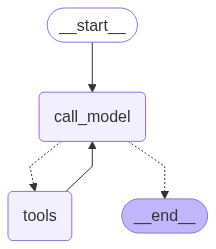

In [10]:
graph

#### 📨 Sending initial query to the graph | 🏗️ XTALLET

In [11]:
result_1 = await graph.ainvoke({"messages": "show me the top headlines from the US in technology"})

#### 🖨️ Printing the latest AI response content | 🏗️ XTALLET

In [12]:
print(result_1["messages"][-1].content)

Here are the top technology headlines from the US:

1. AirPods 4 now starting within $10 of Prime Day low at $99 shipped via Amazon, more - 9to5Toys
2. Google is rolling out a fix for Pixel back button issues - The Verge
3. Sagat can whiff punish from near full-screen with his charged Tiger Uppercut in Street Fighter 6 - EventHubs
4. Apple Sues the New Apple Cinemas at 1000 Van Ness, Claiming Trademark Infringement - SFist
5. A YouTuber Tested The Galaxy Z Fold 7's Durability - Here's What Happened After 200,000 Folds - bgr.com
6. How Virtua Fighter Looks to Bring Innovation and Realism to the 3D Fighting Genre | Evo 2025 - IGN
7. RIP to the Macintosh HD hard drive icon, 2000–2025 - Ars Technica
8. TP-Link’s new travel router delivers Wi-Fi 7 speeds - The Verge
9. Report: ZeniMax’s Cancelled “Project Blackbird” First Look at Creatures & Animations - MP1st
10. CoD Season 5 Battle Pass Adds Sims And Two New Guns In BO6 And Warzone - GameSpot

If you want more details on any of these stor

#### 📦 Printing the full response object | 🏗️ XTALLET

In [13]:
print(result_1)

{'messages': [HumanMessage(content='show me the top headlines from the US in technology', additional_kwargs={}, response_metadata={}, id='7922c0ef-bf15-4365-9595-26fa76a717bc'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_yNMXPz2bDpR4UEVzKQMomZVz', 'function': {'arguments': '{"country":"us","category":"technology","page_size":10}', 'name': 'get_top_headlines'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 189, 'total_tokens': 214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_799e4ca3f1', 'id': 'chatcmpl-C1rE8iGP2GvtBkwEaEPGDt3PSXArM', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--1e298577-b1ee-4ca8-b22b-039e997fea9c-0', tool_calls=[

#### 🔍 Extracting tools used and printing final response | 🏗️ XTALLET

In [14]:
# Extract messages
messages = result_1["messages"]

# Detect used tools
tool_calls = [
    call["name"]
    for msg in messages
    if hasattr(msg, "tool_calls") and msg.tool_calls
    for call in msg.tool_calls
]

# Show used tools with emoji
if tool_calls:
    unique_tools = ", ".join(set(tool_calls))
    print(f"🛠️ Tools used: {unique_tools}")
else:
    print("💬 No tools were used.")

# Show final model response (last AIMessage with content)
final_response = next(
    (msg.content for msg in reversed(messages) if msg.type == "ai" and msg.content.strip()), 
    None
)
if final_response:
    print(f"\n✅ Final response:\n{final_response}")
else:
    print("\n⚠️ No final response from the model.")

🛠️ Tools used: get_top_headlines

✅ Final response:
Here are the top technology headlines from the US:

1. AirPods 4 now starting within $10 of Prime Day low at $99 shipped via Amazon, more - 9to5Toys
2. Google is rolling out a fix for Pixel back button issues - The Verge
3. Sagat can whiff punish from near full-screen with his charged Tiger Uppercut in Street Fighter 6 - EventHubs
4. Apple Sues the New Apple Cinemas at 1000 Van Ness, Claiming Trademark Infringement - SFist
5. A YouTuber Tested The Galaxy Z Fold 7's Durability - Here's What Happened After 200,000 Folds - bgr.com
6. How Virtua Fighter Looks to Bring Innovation and Realism to the 3D Fighting Genre | Evo 2025 - IGN
7. RIP to the Macintosh HD hard drive icon, 2000–2025 - Ars Technica
8. TP-Link’s new travel router delivers Wi-Fi 7 speeds - The Verge
9. Report: ZeniMax’s Cancelled “Project Blackbird” First Look at Creatures & Animations - MP1st
10. CoD Season 5 Battle Pass Adds Sims And Two New Guns In BO6 And Warzone - Gam

#### 📨 Sending a second query with different parameters | 🏗️ XTALLET

In [15]:
result_2 = await graph.ainvoke({"messages": "search news about artificial intelligence in Spanish"})

#### 🔍 Extracting tools used and printing final response (second query) | 🏗️ XTALLET

In [16]:
# Extract messages
messages = result_2["messages"]

# Detect used tools
tool_calls = [
    call["name"]
    for msg in messages
    if hasattr(msg, "tool_calls") and msg.tool_calls
    for call in msg.tool_calls
]

# Show used tools with emoji
if tool_calls:
    unique_tools = ", ".join(set(tool_calls))
    print(f"🛠️ Tools used: {unique_tools}")
else:
    print("💬 No tools were used.")

# Show final model response (last AIMessage with content)
final_response = next(
    (msg.content for msg in reversed(messages) if msg.type == "ai" and msg.content.strip()), 
    None
)
if final_response:
    print(f"\n✅ Final response:\n{final_response}")
else:
    print("\n⚠️ No final response from the model.")


🛠️ Tools used: search_news

✅ Final response:
Aquí tienes algunas noticias recientes en español sobre inteligencia artificial:

1. OpenAI puede hacer historia: negocia una valoración récord de 500.000 millones de dólares. (2025-08-06)
2. El 87 % de los españoles quiere usar la IA para planificar sus viajes, pero exige control humano. (2025-08-06)
3. Google pausará su IA durante olas de calor en EEUU para aliviar la red eléctrica. (2025-08-06)
4. Samsung mejorará sus Smart TV con una versión avanzada de Bixby, su asistente de voz basado en IA. (2025-08-06)
5. Supermicro finaliza su año fiscal con 22.000 millones de dólares en ventas netas, impulsado por IA. (2025-08-06)
6. Palo Alto Networks refuerza su seguridad preventiva mediante IA en Cortex Cloud. (2025-08-06)
7. AMD alcanza ingresos récord en el segundo trimestre, beneficiado por la demanda en IA. (2025-08-06)

Si deseas el enlace o detalles de algún artículo en particular, házmelo saber.


#### 📨 Querying news sources for the UK | 🏗️ XTALLET

In [17]:
result_3 = await graph.ainvoke({"messages": "what are the news sources available in the UK?"})

#### 🔍 Extracting tools used and printing final response (UK news sources) | 🏗️ XTALLET

In [18]:
# Extract messages
messages = result_3["messages"]

# Detect used tools
tool_calls = [
    call["name"]
    for msg in messages
    if hasattr(msg, "tool_calls") and msg.tool_calls
    for call in msg.tool_calls
]

# Show used tools with emoji
if tool_calls:
    unique_tools = ", ".join(set(tool_calls))
    print(f"🛠️ Tools used: {unique_tools}")
else:
    print("💬 No tools were used.")

# Show final model response (last AIMessage with content)
final_response = next(
    (msg.content for msg in reversed(messages) if msg.type == "ai" and msg.content.strip()), 
    None
)
if final_response:
    print(f"\n✅ Final response:\n{final_response}")
else:
    print("\n⚠️ No final response from the model.")

🛠️ Tools used: get_news_sources

✅ Final response:
Here are some of the available news sources in the UK:

1. BBC News – Up-to-the-minute news, breaking news, videos, audio, and feature stories.
2. BBC Sport – Live sports coverage, breaking news, results, videos, and more.
3. FourFourTwo – Football news, features, tactical and statistical analysis.
4. Google News (UK) – Aggregated UK news coverage from various sources.
5. Independent – National UK quality news, features, and supplements.
6. MTV News (UK) – Celebrity news, gossip, and exclusive interviews in music and entertainment.
7. TalkSport – Major sports radio station with live Premier League football and sports talk.
8. The Lad Bible – Popular online community for trending and viral content aimed at younger audiences.
9. The Sport Bible – Large community focused on sports news and viral sports content.

Would you like news from any specific source or topic?
